# Extracting and Visualizing Stock Data

## Setup and Library Imports
In this section, we install and import the required libraries for data extraction, processing, and visualization.

In [15]:
# Install required libraries
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib
!pip install html5lib

In [16]:
# Import required libraries
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import warnings
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)

## Define Graphing Function

This function will be used to visualize stock price and revenue data.

In [17]:
# Function to plot stock price and revenue
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"))
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Plot revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"))
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

## Question 1: Extract Tesla Stock Data

Using yfinance to retrieve historical stock data for Tesla (TSLA).

In [18]:
# Create ticker object for Tesla
tesla = yf.Ticker("TSLA")

# Extract historical stock data
tesla_data = tesla.history(period="max")

# Reset index to make Date a column
tesla_data.reset_index(inplace=True)

# Display first 5 rows
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## Question 2: Extract Tesla Revenue Data

Using web scraping to extract Tesla quarterly revenue data.

In [19]:
# Download webpage containing revenue data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text

# Read tables from HTML
tables = pd.read_html(html_data)

# Extract Tesla revenue table
tesla_revenue = tables[1]
tesla_revenue.columns = ["Date", "Revenue"]

# Clean Revenue column
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(r',|\$', "", regex=True)

# Remove missing or empty values
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]

# Display last 5 rows
tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


## Question 3: Extract GameStop Stock Data

Using yfinance to retrieve historical stock data for GameStop (GME).

In [20]:
# Create ticker object for GameStop
gme = yf.Ticker("GME")

# Extract stock data
gme_data = gme.history(period="max")

# Reset index
gme_data.reset_index(inplace=True)

# Display first 5 rows
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712708,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


## Question 4: Extract GameStop Revenue Data

Using web scraping to extract GameStop quarterly revenue data.

In [21]:
# Download webpage
url2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2 = requests.get(url2).text

# Read tables
tables2 = pd.read_html(html_data_2)

# Extract revenue table
gme_revenue = tables2[1]
gme_revenue.columns = ["Date", "Revenue"]

# Clean Revenue column
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(r',|\$', "", regex=True)

# Remove missing/empty values
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

# Display last 5 rows
gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


## Question 5: Plot Tesla Stock Data

Visualizing Tesla stock price and revenue over time.

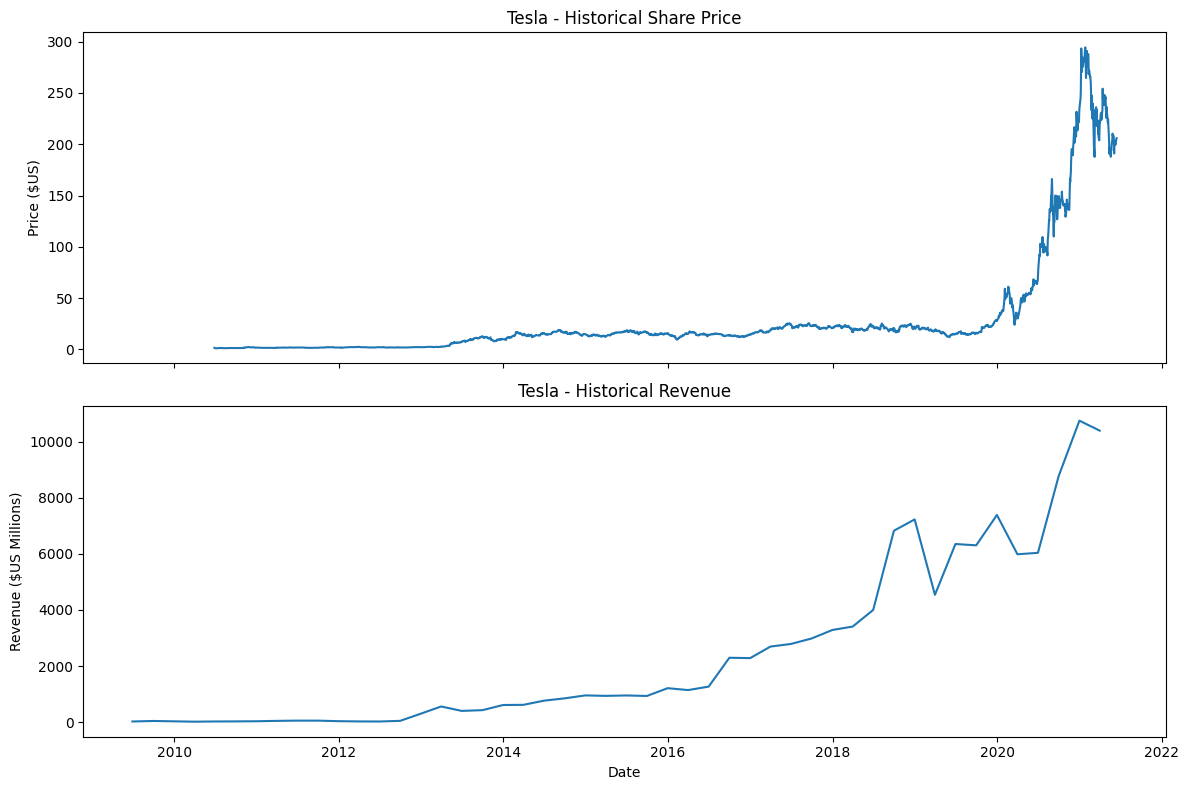

In [22]:
# Plot Tesla graph
make_graph(tesla_data, tesla_revenue, "Tesla")

## Question 6: Plot GameStop Stock Data

Visualizing GameStop stock price and revenue over time.

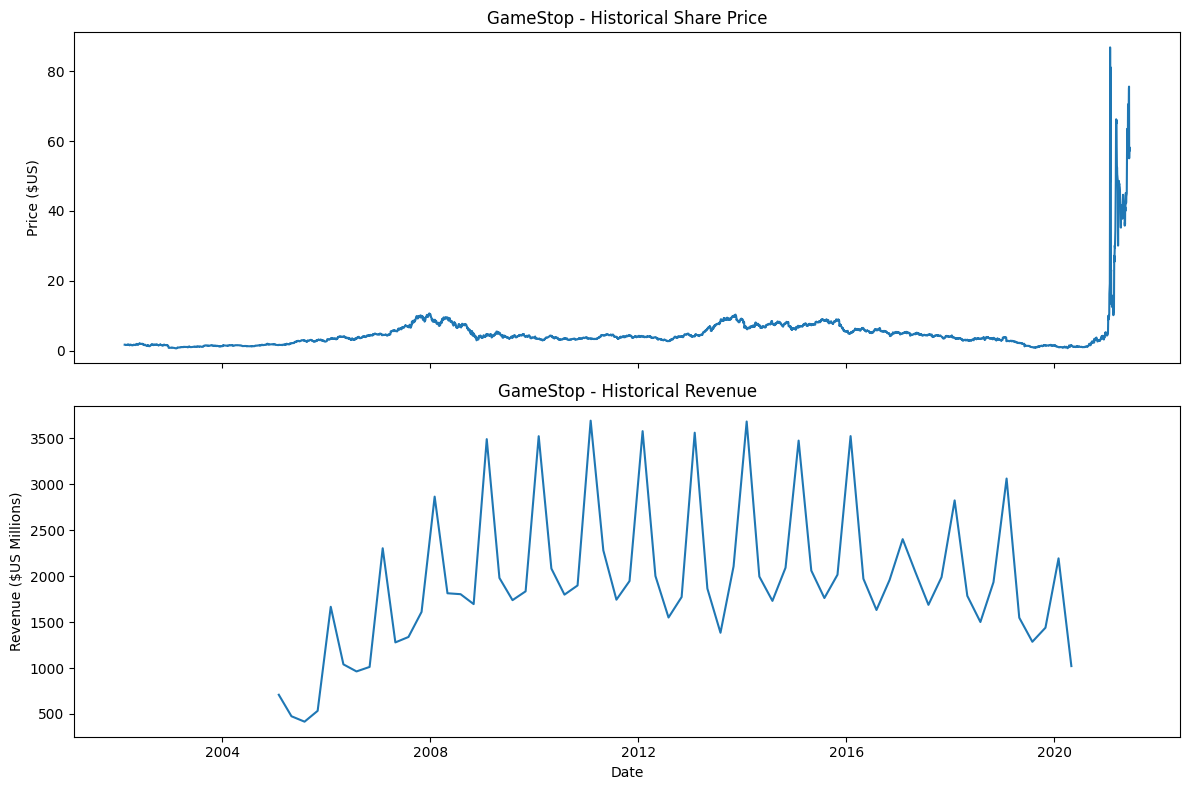

In [23]:
# Plot GameStop graph
make_graph(gme_data, gme_revenue, "GameStop")

In [24]:
tesla_revenue = tables[1].copy()
gme_revenue = tables2[1].copy()